In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 Імпорт даних та перший огляд

In [162]:
df = pd.read_csv('credit_card.csv')
df['age_group'] = pd.cut(df['cardholder_age'], bins=[10, 20, 30, 40, 50, 60, 70], 
                         labels=['10-20', '20-30', '30-40', '40-50', '50-60', '60-70'])

# Створюємо категорії для device_trust_score з конкретними межами
# 0-30: low, 30-60: medium, >60: high
max_score = df['device_trust_score'].max()
df['device_trust_level'] = pd.cut(df['device_trust_score'], 
                                   bins=[0, 30, 60, max_score + 1], 
                                   labels=['low', 'medium', 'high'],
                                   right=False)

df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,age_group,device_trust_level
0,1,84.47,22,Electronics,0,0,66,3,40,0,30-40,high
1,2,541.82,3,Travel,1,0,87,1,64,0,60-70,high
2,3,237.01,17,Grocery,0,0,49,1,61,0,60-70,medium
3,4,164.33,4,Grocery,0,1,72,3,34,0,30-40,high
4,5,30.53,15,Food,0,0,79,0,44,0,40-50,high


### Останні 5 елементів

In [163]:
df.tail()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,age_group,device_trust_level
9995,9996,350.91,22,Food,0,0,99,4,37,0,30-40,high
9996,9997,410.04,5,Clothing,0,0,70,3,25,0,20-30,high
9997,9998,527.75,21,Electronics,0,0,44,2,45,0,40-50,medium
9998,9999,91.20,2,Electronics,0,0,38,0,37,0,30-40,medium
9999,10000,44.06,2,Clothing,0,0,38,0,66,0,60-70,medium


### Інформація про типи даних та кількість

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   transaction_id       10000 non-null  int64   
 1   amount               10000 non-null  float64 
 2   transaction_hour     10000 non-null  int64   
 3   merchant_category    10000 non-null  object  
 4   foreign_transaction  10000 non-null  int64   
 5   location_mismatch    10000 non-null  int64   
 6   device_trust_score   10000 non-null  int64   
 7   velocity_last_24h    10000 non-null  int64   
 8   cardholder_age       10000 non-null  int64   
 9   is_fraud             10000 non-null  int64   
 10  age_group            10000 non-null  category
 11  device_trust_level   10000 non-null  category
dtypes: category(2), float64(1), int64(8), object(1)
memory usage: 801.3+ KB


### Перевірка відсутніх значень

In [165]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
age_group              0
device_trust_level     0
dtype: int64

### Перевірка дублікатів

In [166]:
df.duplicated().sum()

np.int64(0)

---

## 📊 Візуалізація даних


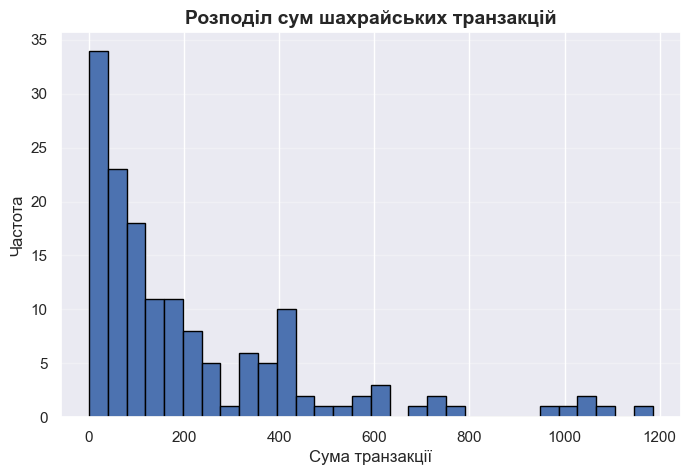

In [167]:
# Гістограма розподілу сум шахрайських транзакцій
plt.figure(figsize=(8, 5))
n, bins, patches = plt.hist(df[df['is_fraud']==1]['amount'], bins=30, edgecolor='black')
plt.title('Розподіл сум шахрайських транзакцій', fontsize=14, fontweight='bold')
plt.xlabel('Сума транзакції', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.show()


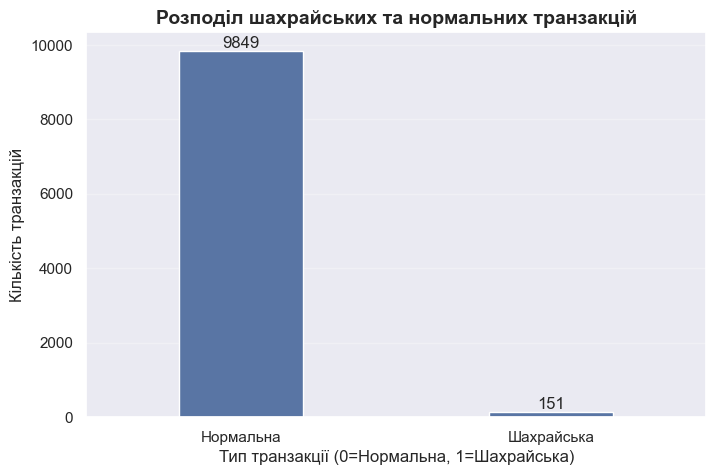

In [168]:
# Розподіл шахрайських та нормальних транзакцій
plt.figure(figsize=(8, 5))
ax = sns.countplot(x="is_fraud", data=df, width=0.4)
plt.title('Розподіл шахрайських та нормальних транзакцій', fontsize=14, fontweight='bold')
plt.xlabel('Тип транзакції (0=Нормальна, 1=Шахрайська)', fontsize=12)
plt.ylabel('Кількість транзакцій', fontsize=12)
plt.xticks([0, 1], ['Нормальна', 'Шахрайська'])

# Додаємо підрахунки на графік
for container in ax.containers:
    ax.bar_label(container)
    
plt.grid(True, alpha=0.3, axis='y')
plt.show()

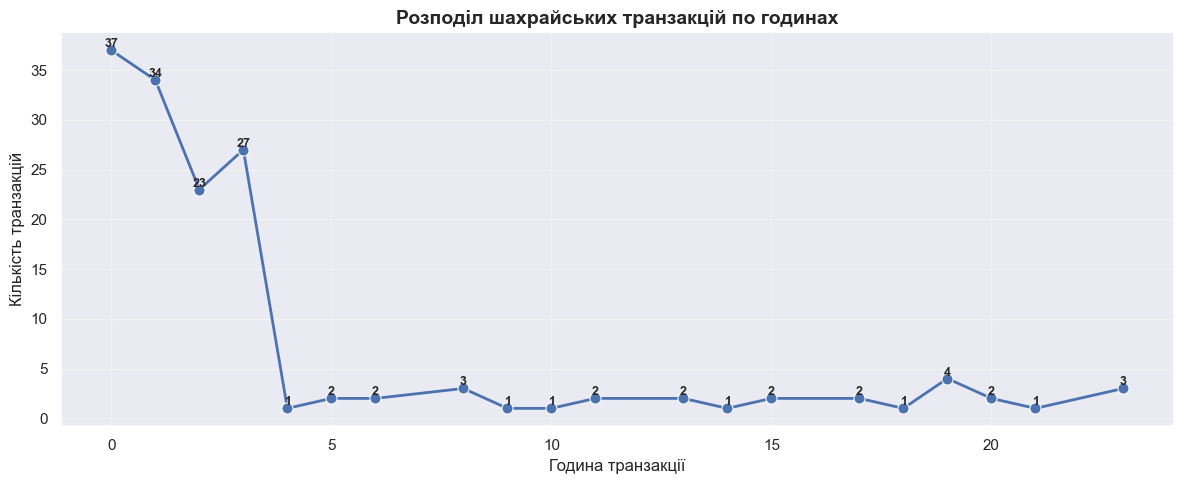

In [169]:
# Створюємо DataFrame з шахрайськими транзакціями
fraud_df = df[df['is_fraud'] == 1]

# Підраховуємо кількість шахрайських транзакцій по годинах
fraud_by_hour = fraud_df['transaction_hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=fraud_by_hour.index, y=fraud_by_hour.values, marker='o', linewidth=2, markersize=8)
plt.title('Розподіл шахрайських транзакцій по годинах', fontsize=14, fontweight='bold')
plt.xlabel('Година транзакції', fontsize=12)
plt.ylabel('Кількість транзакцій', fontsize=12)
plt.grid(True, alpha=0.3)

# Додаємо підписи на кожній точці
for hour, count in zip(fraud_by_hour.index, fraud_by_hour.values):
    plt.text(hour, count, f'{count}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


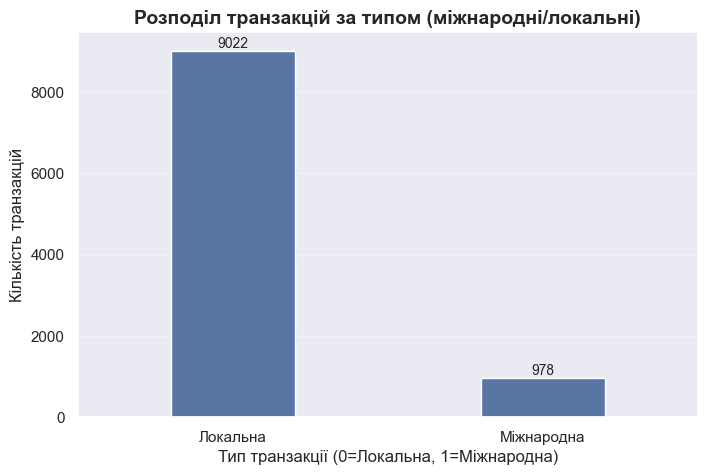

In [170]:
# Розподіл всіх транзакцій за типом (міжнародні/локальні)
foreign_transaction = df['foreign_transaction'].value_counts()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=foreign_transaction.index, y=foreign_transaction.values, width=0.4)
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title('Розподіл транзакцій за типом (міжнародні/локальні)', fontsize=14, fontweight='bold')
plt.xlabel('Тип транзакції (0=Локальна, 1=Міжнародна)', fontsize=12)
plt.ylabel('Кількість транзакцій', fontsize=12)
plt.xticks([0, 1], ['Локальна', 'Міжнародна'])
plt.grid(True, alpha=0.3, axis='y')
plt.show()


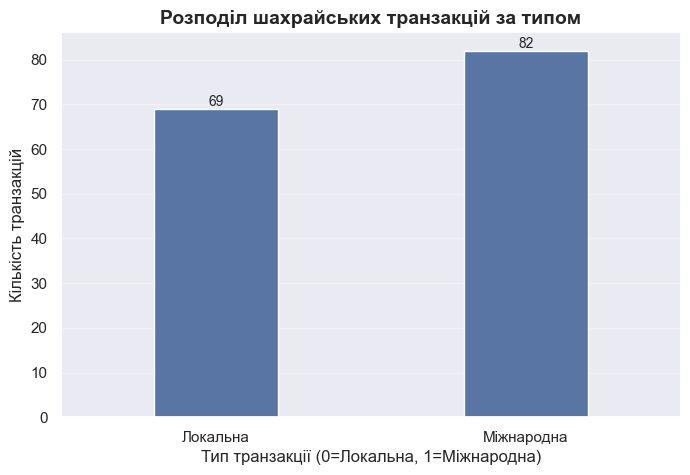

In [171]:
# Розподіл шахрайських транзакцій за типом (міжнародні/локальні)
fraud_by_foreign_transaction = fraud_df['foreign_transaction'].value_counts()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=fraud_by_foreign_transaction.index, y=fraud_by_foreign_transaction.values, width=0.4)
for container in ax.containers:
    ax.bar_label(container, fontsize=10)
    
plt.title('Розподіл шахрайських транзакцій за типом', fontsize=14, fontweight='bold')
plt.xlabel('Тип транзакції (0=Локальна, 1=Міжнародна)', fontsize=12)
plt.ylabel('Кількість транзакцій', fontsize=12)
plt.xticks([0, 1], ['Локальна', 'Міжнародна'])
plt.grid(True, alpha=0.3, axis='y')
plt.show()




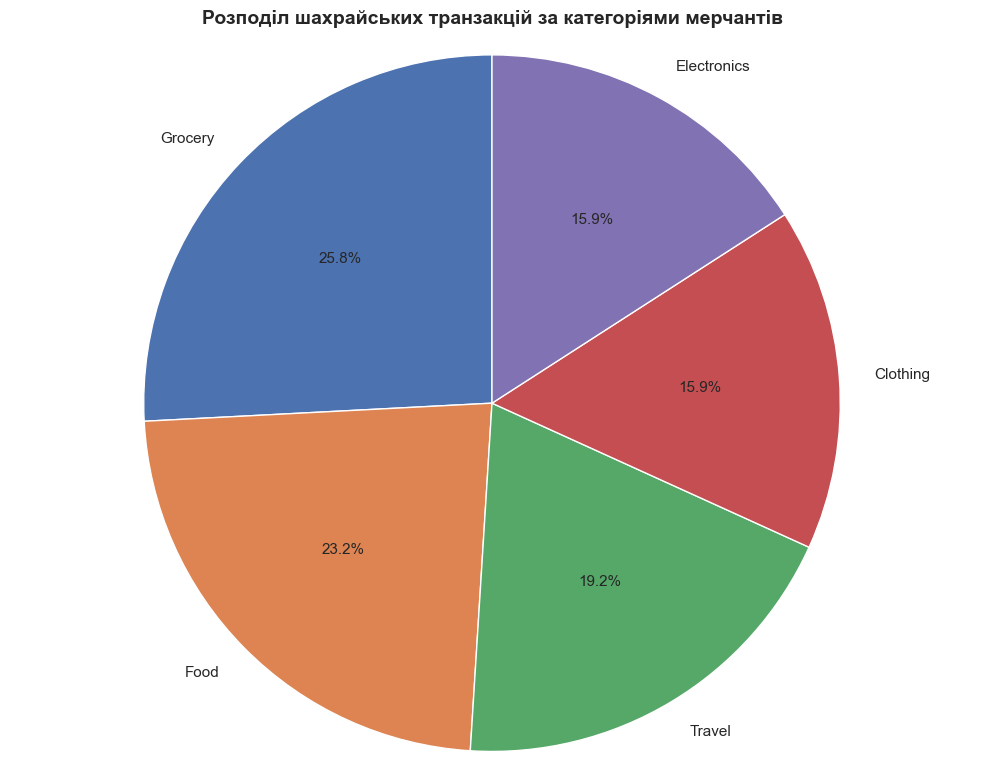

In [172]:
# Кругова діаграма розподілу шахрайських транзакцій по категоріях
category_counts = fraud_df['merchant_category'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(category_counts.values, 
        labels=category_counts.index, 
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 11})
plt.title('Розподіл шахрайських транзакцій за категоріями мерчантів', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

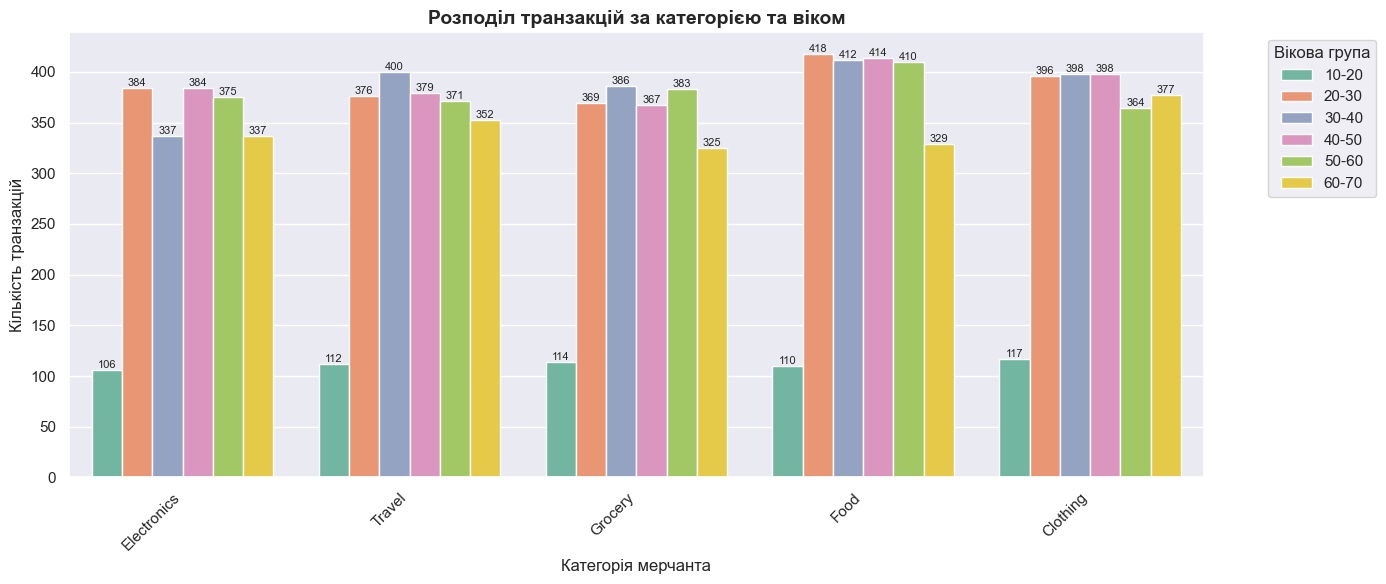

In [173]:
# Створюємо згрупований bar chart: категорії (основні групи) та вік (підгрупи)
plt.figure(figsize=(14, 6))

# Використовуємо countplot з hue для групування
ax = sns.countplot(data=df, x='merchant_category', hue='age_group', palette='Set2')

plt.title('Розподіл транзакцій за категорією та віком', fontsize=14, fontweight='bold')
plt.xlabel('Категорія мерчанта', fontsize=12)
plt.ylabel('Кількість транзакцій', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Вікова група', bbox_to_anchor=(1.05, 1), loc='upper left')

# Додаємо підрахунки на стовпці
for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.tight_layout()
plt.show()


In [174]:
# Статистика сум шахрайських транзакцій
mean_amount = fraud_df['amount'].mean()
median_amount = fraud_df['amount'].median()

print('📊 Статистика сум шахрайських транзакцій:')
print(f'Середнє значення: {mean_amount:.2f}')
print(f'Медіанне значення: {median_amount:.2f}')

📊 Статистика сум шахрайських транзакцій:
Середнє значення: 216.18
Медіанне значення: 118.94


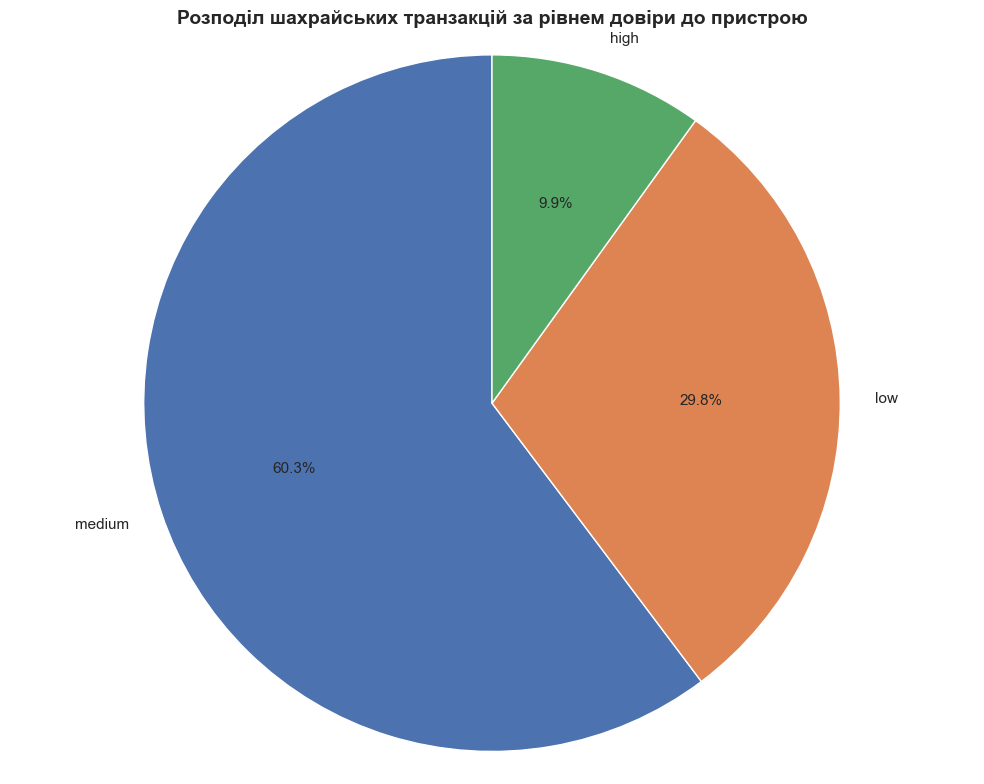

In [183]:
# Кругова діаграма розподілу шахрайських транзакцій за рівнем довіри до пристрою
category_counts = fraud_df['device_trust_level'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(category_counts.values, 
        labels=category_counts.index, 
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 11})
plt.title('Розподіл шахрайських транзакцій за рівнем довіри до пристрою', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()


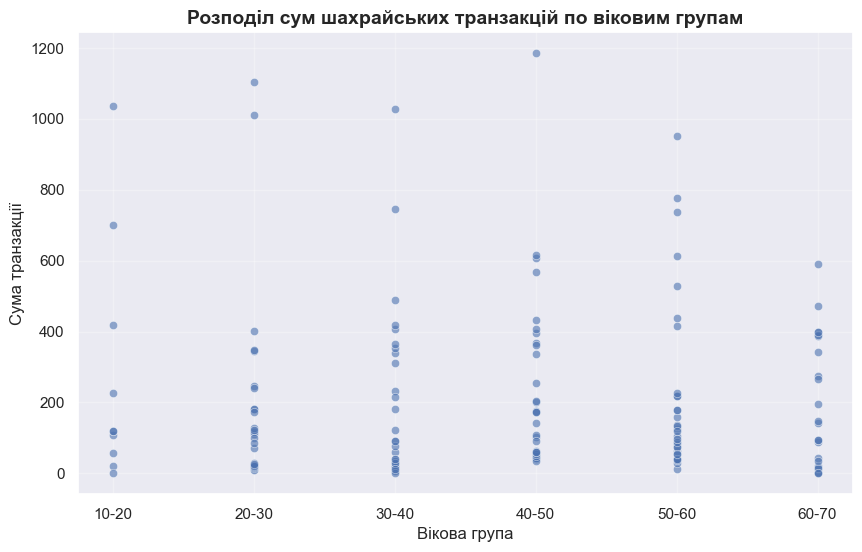

In [176]:
# Виправлений scatter plot: Сума транзакцій по віковим групам (шахрайські транзакції)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_group', y='amount', data=fraud_df, alpha=0.6)
plt.title('Розподіл сум шахрайських транзакцій по віковим групам', fontsize=14, fontweight='bold')
plt.xlabel('Вікова група', fontsize=12)
plt.ylabel('Сума транзакції', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\den\AppData\Local\Temp\ipykernel_8008\2796822582.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fraud_df, x='age_group', y='amount', palette='Set2')


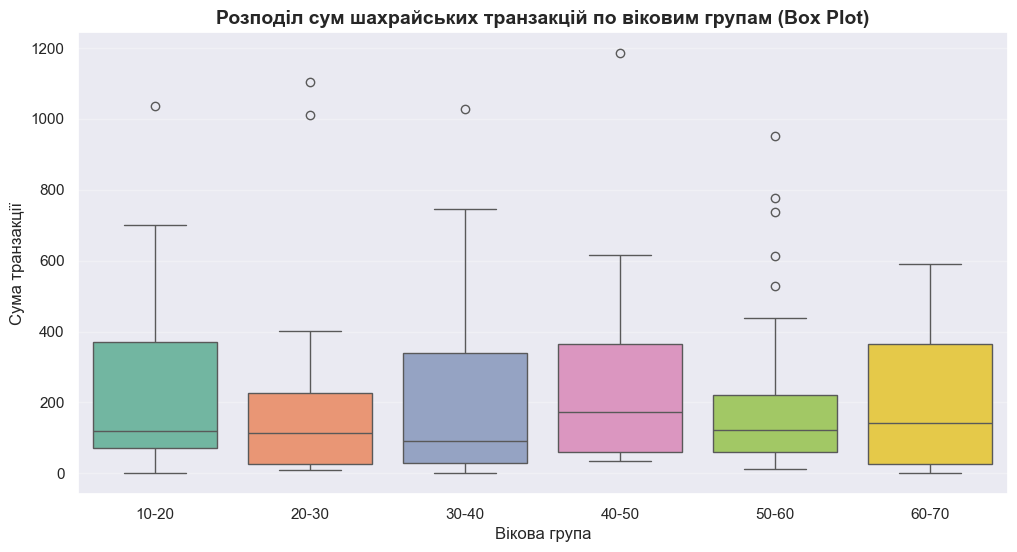

In [184]:
# Box plot: Краща візуалізація розподілу сум по віковим групам
plt.figure(figsize=(12, 6))
sns.boxplot(data=fraud_df, x='age_group', y='amount', palette='Set2')
plt.title('Розподіл сум шахрайських транзакцій по віковим групам (Box Plot)', fontsize=14, fontweight='bold')
plt.xlabel('Вікова група', fontsize=12)
plt.ylabel('Сума транзакції', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.show()


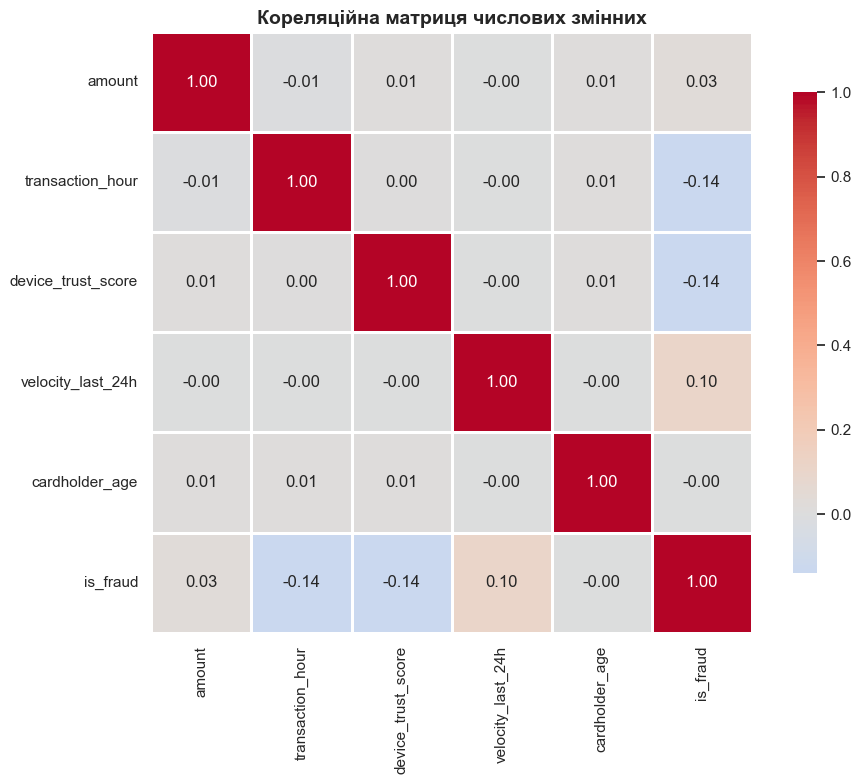

In [185]:
# Heatmap кореляційної матриці для числових змінних
numeric_cols = ['amount', 'transaction_hour', 'device_trust_score', 
                'velocity_last_24h', 'cardholder_age', 'is_fraud']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Кореляційна матриця числових змінних', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\den\AppData\Local\Temp\ipykernel_8008\1951071773.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=fraud_df, x='device_trust_level', order=['low', 'medium', 'high'],


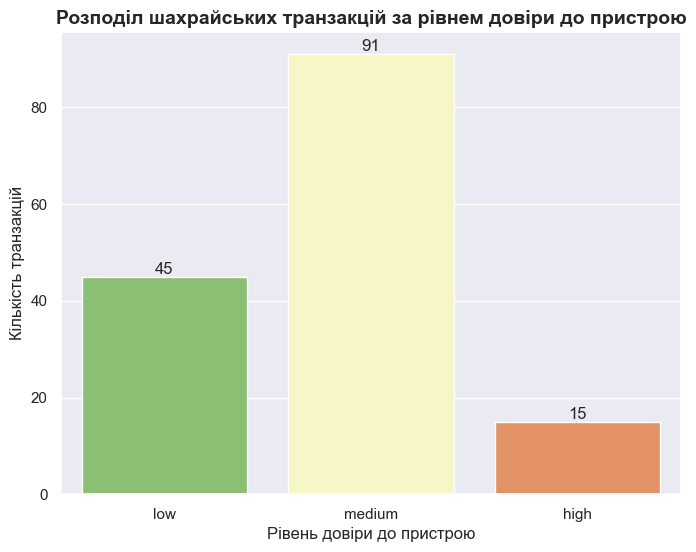

In [ ]:
# Розподіл рівня довіри до пристрою для шахрайських транзакцій
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=fraud_df, x='device_trust_level', order=['low', 'medium', 'high'], 
                   palette='RdYlGn_r')
plt.title('Розподіл шахрайських транзакцій за рівнем довіри до пристрою', fontsize=14, fontweight='bold')
plt.xlabel('Рівень довіри до пристрою', fontsize=12)
plt.ylabel('Кількість транзакцій', fontsize=12)

# Додаємо підрахунки
for container in ax.containers:
    ax.bar_label(container)
    
plt.show()


Порівняння сум транзакцій:
            mean  median     std
is_fraud                        
0         175.33  122.11  173.99
1         216.18  118.94  248.12

0 = Нормальна транзакція, 1 = Шахрайська транзакція


C:\Users\den\AppData\Local\Temp\ipykernel_8008\1618253863.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='is_fraud', y='amount', estimator='mean', palette='viridis')


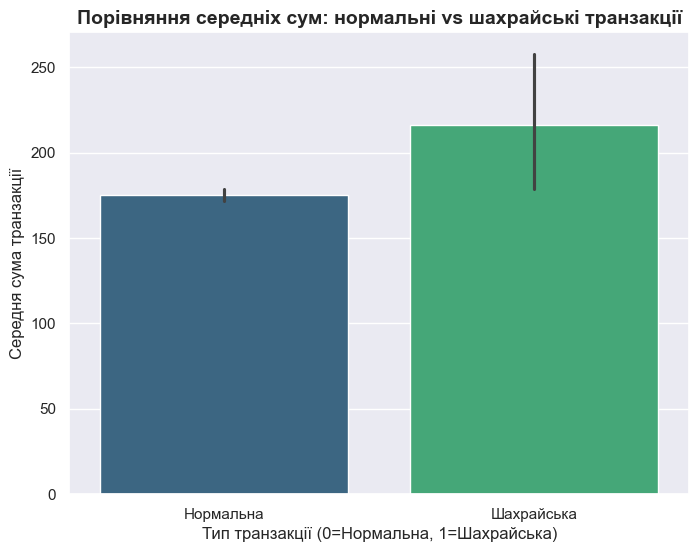

In [187]:
# Порівняння середніх сум транзакцій: шахрайські vs нормальні
comparison = df.groupby('is_fraud')['amount'].agg(['mean', 'median', 'std']).round(2)
print("Порівняння сум транзакцій:")
print(comparison)
print("\n0 = Нормальна транзакція, 1 = Шахрайська транзакція")

plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='is_fraud', y='amount', estimator='mean', palette='viridis')
plt.title('Порівняння середніх сум: нормальні vs шахрайські транзакції', fontsize=14, fontweight='bold')
plt.xlabel('Тип транзакції (0=Нормальна, 1=Шахрайська)', fontsize=12)
plt.ylabel('Середня сума транзакції', fontsize=12)
plt.xticks([0, 1], ['Нормальна', 'Шахрайська'])
plt.show()


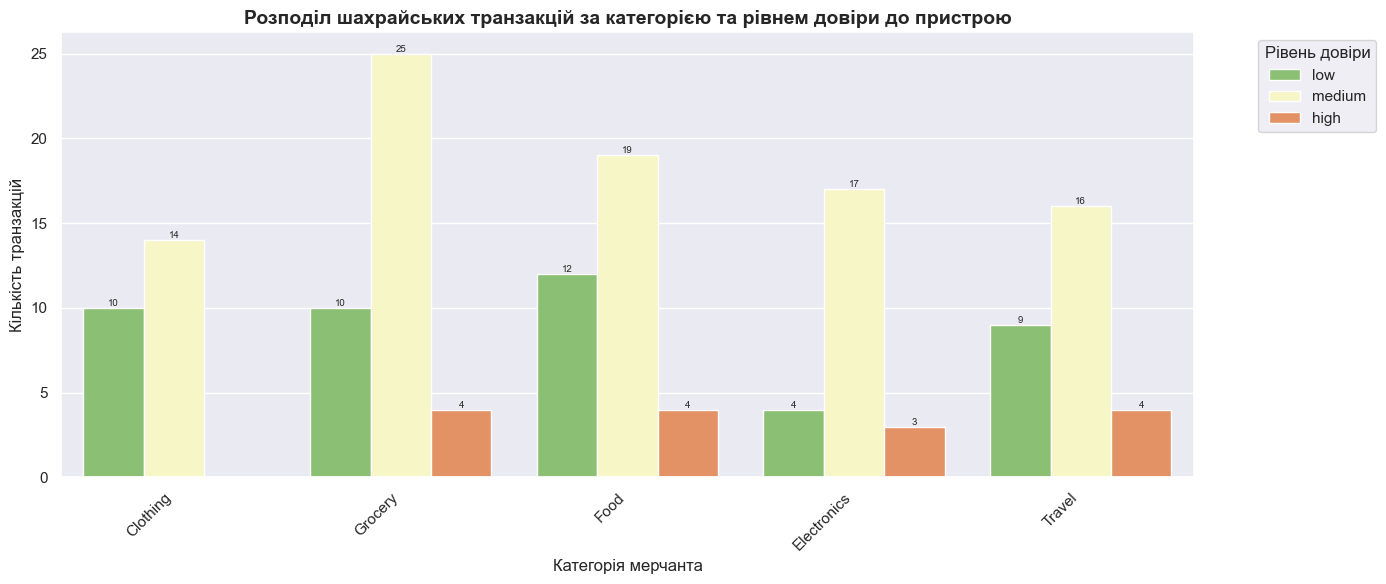

In [181]:
# Згрупований bar chart: категорії та рівень довіри до пристрою (для шахрайських транзакцій)
plt.figure(figsize=(14, 6))
ax = sns.countplot(data=fraud_df, x='merchant_category', hue='device_trust_level', 
                   palette='RdYlGn_r', hue_order=['low', 'medium', 'high'])
plt.title('Розподіл шахрайських транзакцій за категорією та рівнем довіри до пристрою', 
          fontsize=14, fontweight='bold')
plt.xlabel('Категорія мерчанта', fontsize=12)
plt.ylabel('Кількість транзакцій', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Рівень довіри', bbox_to_anchor=(1.05, 1), loc='upper left')

# Додаємо підрахунки
for container in ax.containers:
    ax.bar_label(container, fontsize=7)

plt.tight_layout()
plt.show()


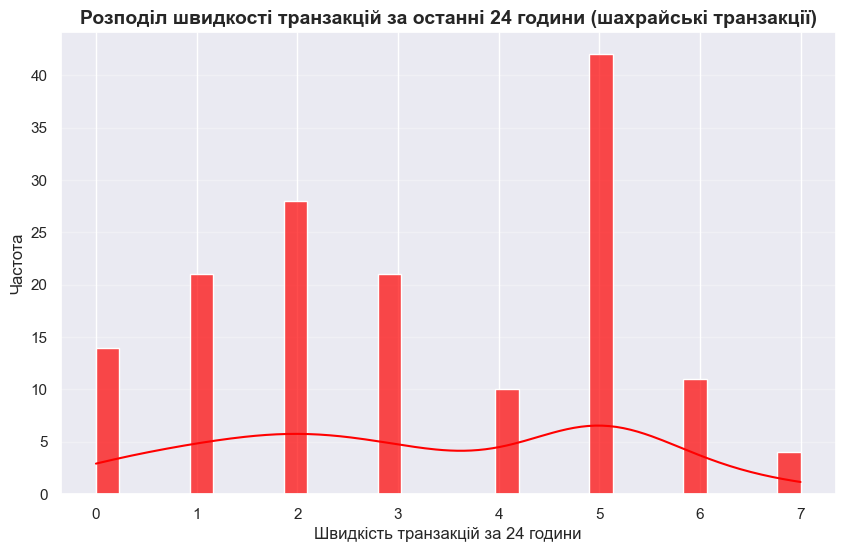

In [182]:
# Візуалізація розподілу velocity_last_24h для шахрайських транзакцій
plt.figure(figsize=(10, 6))
sns.histplot(data=fraud_df, x='velocity_last_24h', bins=30, kde=True, color='red', alpha=0.7)
plt.title('Розподіл швидкості транзакцій за останні 24 години (шахрайські транзакції)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Швидкість транзакцій за 24 години', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.show()


<style>
.analysis-box {
    font-size: 15px;
    line-height: 1.6;
    max-width: 900px;
    margin: 0 auto;
}

/* Заголовки */
.analysis-box h2 {
    margin-top: 25px;
    margin-bottom: 10px;
}

.analysis-box h3 {
    margin-top: 20px;
    margin-bottom: 8px;
}

/* Таблиця */
.analysis-box table {
    border-collapse: collapse;
    width: 100%;
    margin: 12px 0 18px 0;
}

.analysis-box th,
.analysis-box td {
    border: 1px solid #aaa;
    padding: 8px 12px;
    text-align: center;
}

.analysis-box th {
    font-weight: bold;
}

/* Текст */
.analysis-box p {
    margin: 8px 0;
}

/* Списки */
.analysis-box ul,
.analysis-box ol {
    margin: 6px 0 12px 20px;
}

.analysis-box li {
    margin-bottom: 4px;
}
</style>

<div class="analysis-box">

<h2>📈 Додаткові висновки та спостереження</h2>

<h3>💰 Статистичний аналіз сум транзакцій</h3>

<table>
<tr>
  <th>Показник</th>
  <th>Нормальні транзакції</th>
  <th>Шахрайські транзакції</th>
</tr>
<tr>
  <td>Середнє значення</td>
  <td>175.33</td>
  <td><b>216.18 ⬆️</b></td>
</tr>
<tr>
  <td>Медіана</td>
  <td>122.11</td>
  <td>118.94</td>
</tr>
<tr>
  <td>Стандартне відхилення</td>
  <td>173.99</td>
  <td><b>248.12 ⬆️</b></td>
</tr>
</table>

<p><b>Висновки:</b></p>
<ul>
  <li>Шахрайські транзакції мають вищу середню суму (~23%).</li>
  <li>Медіанні значення близькі — переважають середні суми.</li>
  <li>Вища варіативність сум у шахрайських операціях.</li>
</ul>

<h3>🔗 Кореляційний аналіз</h3>
<p>
Кореляційна матриця дозволяє виявити взаємозв’язки між факторами
та шахрайською поведінкою.
</p>

<h3>⚠️ Комбіновані фактори ризику</h3>
<ul>
  <li>🌙 Нічний час (00:00–04:00)</li>
  <li>🌍 Міжнародна транзакція</li>
  <li>🔒 Низький або середній рівень довіри до пристрою</li>
  <li>⚡ ≥5 транзакцій за 24 години</li>
  <li>🏪 Категорії «Їжа» та «Продуктові магазини»</li>
</ul>

<h3>💡 Рекомендації</h3>
<ol>
  <li>Реалізувати скоринг ризику.</li>
  <li>Алерти для нічних швидких транзакцій.</li>
  <li>Додаткові перевірки міжнародних операцій.</li>
  <li>Тимчасове блокування при підозрілих патернах.</li>
</ol>

</div>
